### Build a Basic ChatBot with LangGraph(Graph API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [3]:
import os
from pathlib import Path
from langchain_groq import ChatGroq

# 1. Read the line we just confirmed is there
env_file_path = Path.cwd().parent / ".env"
with open(env_file_path, "r", encoding="utf-8") as f:
    line = f.read().splitlines()[0]

# 2. Extract the key directly from the text split
secret_key = line.split("=", 1)[1].strip()

# 3. Explicitly inject it into os.environ for LangGraph nodes to see
os.environ["GROQ_API_KEY"] = secret_key

# 4. Pass it directly to ChatGroq to guarantee it binds right now
llm = ChatGroq(
    model="llama3-8b-8192",
    groq_api_key=secret_key
)

print("✅ Model successfully initialized with the updated key!")

✅ Model successfully initialized with the updated key!


In [4]:

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama3-8b-8192")

In [5]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Llama 3 8B', 'status': 'deprecated', 'release_date': '2024-04-18', 'last_updated': '2024-04-18', 'open_weights': True, 'max_input_tokens': 8192, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F0178ADF90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F0178AE990>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:

## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:

graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

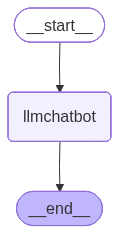

In [8]:

## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
import os
from langchain_groq import ChatGroq

# Re-initialize using a supported, active model
llm = ChatGroq(
    model="llama-3.1-8b-instant",  # Updated to a valid active model ID
    groq_api_key=os.environ["GROQ_API_KEY"]
)

print("✅ Model updated to an active version successfully!")

✅ Model updated to an active version successfully!


In [10]:
response = graph.invoke({"messages": "Hi"})
print(response)

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='1641d332-174e-48f6-bc06-fadf2f7d27fb'), AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.030681161, 'completion_tokens_details': None, 'prompt_time': 0.005379809, 'prompt_tokens_details': None, 'queue_time': 0.048548921, 'total_time': 0.03606097}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eee0f-f42c-7712-b134-32edf68bc59e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]}


In [11]:

response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [12]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How can I assist you today?


### Chatbot with Tool

In [13]:
import os
from pathlib import Path
from langchain_tavily import TavilySearch

# 1. Read your .env file cleanly
env_file_path = Path.cwd().parent / ".env"

tavily_key = None
with open(env_file_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip().startswith("TAVILY_API_KEY"):
            tavily_key = line.split("=", 1)[1].strip().strip("'\"")
            break

# 2. Inject it into os.environ and initialize the tool
if tavily_key:
    os.environ["TAVILY_API_KEY"] = tavily_key
    
    # Initialize the tool by passing the key explicitly
    tool = TavilySearch(max_results=2, tavily_api_key=tavily_key)
    print("🎉 Success! Tavily search tool initialized completely.")
    
    # 3. Test it out!
    print("\nTesting tool invocation:")
    print(tool.invoke("What is langgraph"))
else:
    print("❌ Could not find a line starting with 'TAVILY_API_KEY' in your .env file.")
    print("Please double check that you added it and saved the file.")

🎉 Success! Tavily search tool initialized completely.

Testing tool invocation:
{'query': 'What is langgraph', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial', 'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?', 'content': "# LangGraph Tutorial: What Is LangGraph and How to Use It? LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. Imagine you're building a complex, multi-agent large language model (LLM) application. It's exciting, but it comes with challenges: managing the state of various agents, coordinating their interactions, and handling errors effectively. LangGraph provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured manner. The core concepts of LangGraph include: graph structure, 

In [14]:

## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [15]:
tools = [tool,multiply]

In [16]:
llm_with_tool=llm.bind_tools(tools)

In [17]:
llm_with_tool


_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F017951090>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F017952210>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

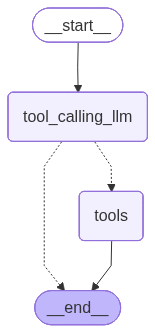

In [18]:

## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
response=graph.invoke({"messages":"What is the recent ai news"})


In [20]:
response['messages'][-1].content

'{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-bezos-predicts-labor-shortage", "title": "Fox News AI Newsletter: Bezos predicts labor shortage - Fox News", "score": 0.62000114, "published_date": "Fri, 19 Jun 2026 13:11:08 GMT", "content": "* #### Fox News AI Newsletter: Top 12 takeaways from Apple\'s new AI features. ## Stay up to date on the latest AI technology advancements and learn about the challenges and opportunities AI presents. By Fox News Staff  Fox News. ### **Welcome to Fox News’ Artificial Intelligence newsletter with the latest AI technology advancements.**. **POWER STRUGGLE:** As data center projects continue to get shut down across the country, \\"Shark Tank\\" star Kevin O\'Leary and other investors are warning that the facilities are needed to compete with China in the artificial intelligence race. **TABLES TURNED:** As artificial intelligence (AI) companies race t

In [21]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (jr76rxezk)
 Call ID: jr76rxezk
  Args:
    query: recent ai news
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-bezos-predicts-labor-shortage", "title": "Fox News AI Newsletter: Bezos predicts labor shortage - Fox News", "score": 0.62000114, "published_date": "Fri, 19 Jun 2026 13:11:08 GMT", "content": "* #### Fox News AI Newsletter: Top 12 takeaways from Apple's new AI features. ## Stay up to date on the latest AI technology advancements and learn about the challenges and opportunities AI presents. By Fox News Staff  Fox News. ### **Welcome to Fox News

In [22]:

response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (ktmf89h6b)
 Call ID: ktmf89h6b
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [23]:

response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (qs9np0yfa)
 Call ID: qs9np0yfa
  Args:
    query: Recent AI news
    time_range: day
    topic: news
  multiply (s43yhz5ex)
 Call ID: s43yhz5ex
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bloomberg.com/news/articles/2026-06-21/mass-affluent-lose-allure-for-wealth-managers-navigating-ai", "title": "The ‘Mass Affluent’ Are Losing Their Allure for Wealth Managers Navigating AI - Bloomberg", "score": 0.57952, "published_date": "Sun, 21 Jun 2026 12:00:00 GMT", "content": "# The ‘Mass Affluent’ Are Losing Their Allure for Wealth Managers Navigating A

### ReAct Agent Architecture 

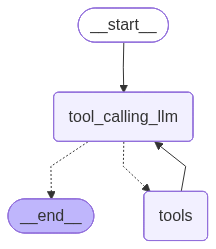

In [24]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ayqkc8fn5)
 Call ID: ayqkc8fn5
  Args:
    query: Recent AI news
    time_range: day
    topic: news
  multiply (nk9vm6p22)
 Call ID: nk9vm6p22
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bloomberg.com/news/articles/2026-06-21/mass-affluent-lose-allure-for-wealth-managers-navigating-ai", "title": "The ‘Mass Affluent’ Are Losing Their Allure for Wealth Managers Navigating AI - Bloomberg", "score": 0.57952, "published_date": "Sun, 21 Jun 2026 12:00:00 GMT", "content": "# The ‘Mass Affluent’ Are Losing Their Allure for Wealth Managers Navigating A

### Adding memory in Agentic Graph

In [27]:
response=graph.invoke({"messages":"Hello my name is raghav"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is raghav
================================== Ai Message ==================================

Nice to meet you, Raghav.


In [28]:

response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have any information about your name. If you would like to share it with me, I can try to help you with something else.


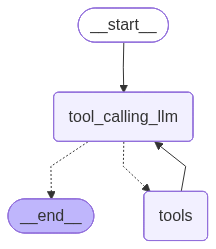

In [29]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is raghav"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Krish', additional_kwargs={}, response_metadata={}, id='892e454d-d3b7-4d8b-bd7e-5f351ba604fd'),
  AIMessage(content="Hello Krish, it's nice to meet you. Is there something I can help you with today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 1750, 'total_tokens': 1771, 'completion_time': 0.033386464, 'completion_tokens_details': None, 'prompt_time': 0.159272276, 'prompt_tokens_details': None, 'queue_time': 0.049398303, 'total_time': 0.19265874}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eee12-9ded-7982-88e6-207ab2854bba-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1750, 'output_tokens': 21, 'total_tokens': 1771}),
  HumanMessage(content='Hi my name is raghav', additional_kwargs={}, response_metadata={}, i

In [33]:
response['messages'][-1].content

"Hello Raghav. I'm glad you introduced yourself, though I had already been chatting with another person named Krish. What can I assist you with today?"

In [34]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Raghav.


In [35]:

response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Your name is Raghav.


### Streaming

In [36]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [37]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

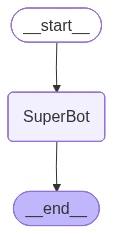

In [38]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [39]:
config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='9e1d44a8-a0d9-4f9d-b460-11b62e1dc505'),
  AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'm happy to chat with you about it. Which aspect of cricket do you enjoy the most - batting, bowling, fielding, or following international tournaments like the ICC World Cup?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 45, 'total_tokens': 97, 'completion_time': 0.068709581, 'completion_tokens_details': None, 'prompt_time': 0.002522495, 'prompt_tokens_details': None, 'queue_time': 0.052616565, 'total_time': 0.071232076}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eee15-16d4-7663-8a1b-5fde805a8b31-0', tool_calls=[], invalid_tool_calls=[], usage_

In [40]:
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Krish! I'm glad to hear that you like cricket. It's a great sport with a huge following around the world. Which team do you support? Are you a fan of international teams like India, England, or Australia, or do you have a favorite domestic team?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 45, 'total_tokens': 106, 'completion_time': 0.104629581, 'completion_tokens_details': None, 'prompt_time': 0.002551345, 'prompt_tokens_details': None, 'queue_time': 0.048991375, 'total_time': 0.107180926}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eee15-5aff-73c1-b357-112cc9fe71ce-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 61, 'total_tokens': 106})]}}


In [41]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='f6b8f083-d9e3-41db-a913-f6b6b749a173'), AIMessage(content="Nice to meet you, Krish! I'm glad to hear that you like cricket. It's a great sport with a huge following around the world. Which team do you support? Are you a fan of international teams like India, England, or Australia, or do you have a favorite domestic team?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 45, 'total_tokens': 106, 'completion_time': 0.104629581, 'completion_tokens_details': None, 'prompt_time': 0.002551345, 'prompt_tokens_details': None, 'queue_time': 0.048991375, 'total_time': 0.107180926}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eee15-5aff-73c1-b357-112cc9fe71ce-0', tool_calls=[], i

In [42]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Krish! Cricket is an amazing sport, isn't it? Which team is your favorite, and do you have a favorite player? Are you an avid follower of Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 45, 'total_tokens': 94, 'completion_time': 0.149488597, 'completion_tokens_details': None, 'prompt_time': 0.011433472, 'prompt_tokens_details': None, 'queue_time': 0.054458148, 'total_time': 0.160922069}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eee16-36b7-7621-963f-d3ee89d202d6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 49, 'total_tokens': 94})]}}


In [43]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='eaa0a2c7-7041-4547-8c0f-0c4b699c7dcf'), AIMessage(content="Nice to meet you, Krish! Cricket is an amazing sport, isn't it? Which team is your favorite, and do you have a favorite player? Are you an avid follower of Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 45, 'total_tokens': 94, 'completion_time': 0.149488597, 'completion_tokens_details': None, 'prompt_time': 0.011433472, 'prompt_tokens_details': None, 'queue_time': 0.054458148, 'total_time': 0.160922069}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eee16-36b7-7621-963f-d3ee89d202d6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 49, '

In [44]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019eee16-79d4-7ef2-9562-d020d4707a76', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='843813ba-298c-49ba-b185-2d819c06b148')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019eee16-79d7-73a2-a739-57d3a9a8392b', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:4681af56-be8d-32a4-65e4-0725c06fe00b'}, 'parent_ids': ['019eee16-79d4-7ef2-9562-d020d4707a76']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':